# **DESARROLLO CASO 7 SERIES DE TIEMPO - UK_DAILY_FLIGHTS**
- Sebastián Molina Puerta.
- Pablo Mesa Hernández.
- Sergio Andrés Morales Toro.
- Wendy Rocío Arévalo Mariño.
- Santiago Estrada Bernal.

# **1. Entendimiento del problema**
Como parte de la publicación de indicadores en tiempo real sobre la actividad económica y el cambio social en el Reino Unido, se quiere conocer cuantos vuelos se realizan diaramente en el país. Para esto, los números de vuelo diarios están disponibles en el panel de control proporcionado por la Organización Europea para la Seguridad de la Navegación Aérea (EUROCONTROL).

# **2. Enfoque Analítico**
Se construirá un modelo de regresión basado en series de tiempo que permita estimar el número diario de vuelos en el Reino Unido con el menor MAPE posible.

# **3. Requerimiento de Datos**
Se requieren los datos del numero diario de vuelos en el Reino Unido entre el 02/01/2019 y el 23/01/2022

# **4. Recolección de Datos**

In [3]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [4]:
data = fetch_dataset(name='uk_daily_flights')
data.index.name = 'datetime'

╭──────────────────────────────── uk_daily_flights ────────────────────────────────╮
│ Description:                                                                     │
│ Daily number of flights in UK from 02/01/2019 to 23/01/2022.                     │
│                                                                                  │
│ Source:                                                                          │
│ Experimental statistics published as part of the Economic activity and social    │
│ change in the UK, real-time indicators release, Published 27 January 2022. Daily │
│ flight numbers are available in the dashboard provided by the European           │
│ Organisation for the Safety of Air Navigation (EUROCONTROL). https://www.ons.gov │
│ .uk/economy/economicoutputandproductivity/output/bulletins/economicactivityandso │
│ cialchangeintheukrealtimeindicators/latest                                       │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/uk_daily_flights.csv                                          │
│                                                                                  │
│ Shape: 1118 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [5]:
data

,Number of flights
datetime,
2019-01-02,5147
2019-01-03,5518
2019-01-04,5588
2019-01-05,4798
2019-01-06,5329
...,...
2022-01-19,2084
2022-01-20,2408
2022-01-21,2801


# **5. Exploración de Datos**
- Identificar los patrones estacionales de la serie.
- Determinar la estacionariedad.

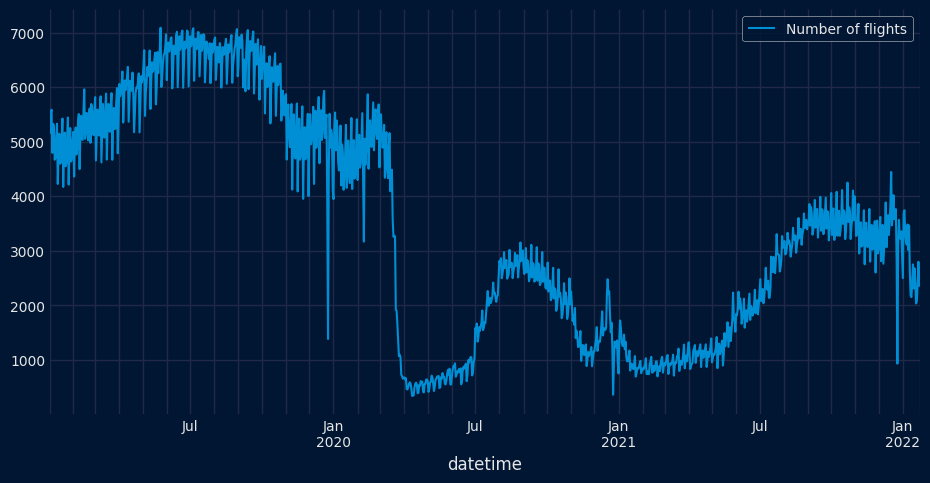

In [6]:
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize=(10, 5))
data.plot(ax=ax)
ax.legend()
plt.show()

Debido a la naturaleza de los datos, se decidió eliminar aquellos en el periodo de pandemia (enero 2019 - junio 2020) para evitar que estos afectaran el modelo.

In [10]:
import pandas as pd
data.index = pd.to_datetime(data.index)          
data_reduced = data.loc['2020-06-01':].copy()      

print(data_reduced.shape)
data_reduced.head()

(602, 1)


,Number of flights
datetime,
2020-06-01,714
2020-06-02,819
2020-06-03,891
2020-06-04,888
2020-06-05,939


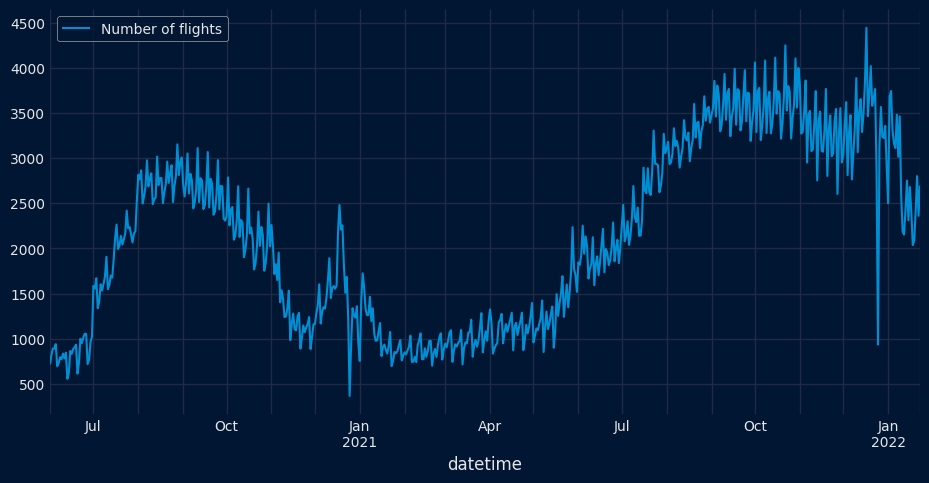

In [11]:
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize=(10, 5))
data_reduced.plot(ax=ax)
ax.legend()
plt.show()

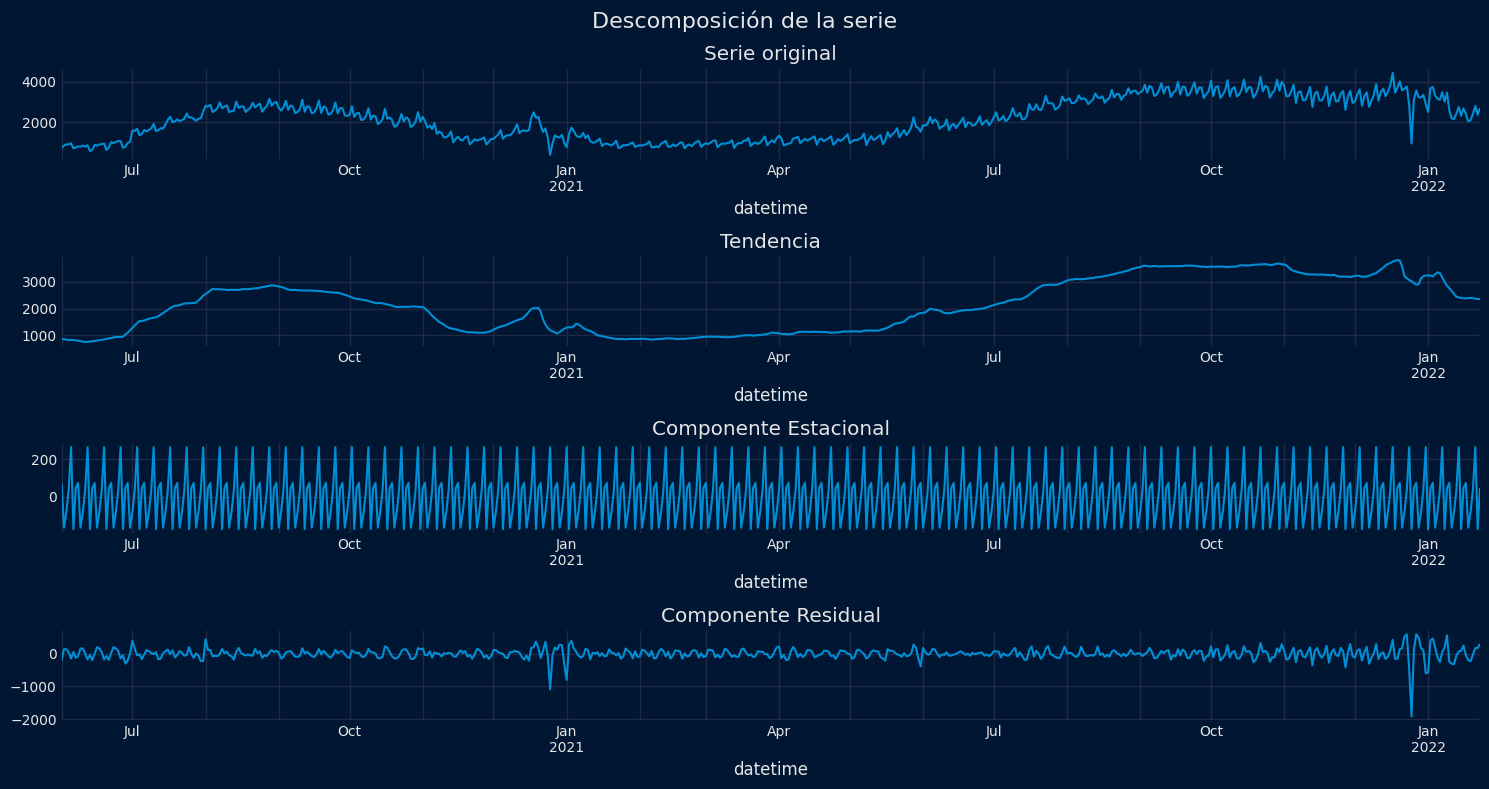

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

res_decompose = seasonal_decompose(data_reduced['Number of flights'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4,1, figsize=(15,8))
res_decompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie original')
res_decompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')
res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Componente Estacional')
res_decompose.resid.plot(ax=ax[3])
ax[3].set_title('Componente Residual')
fig.suptitle('Descomposición de la serie', fontsize=16)
plt.tight_layout()
plt.show()

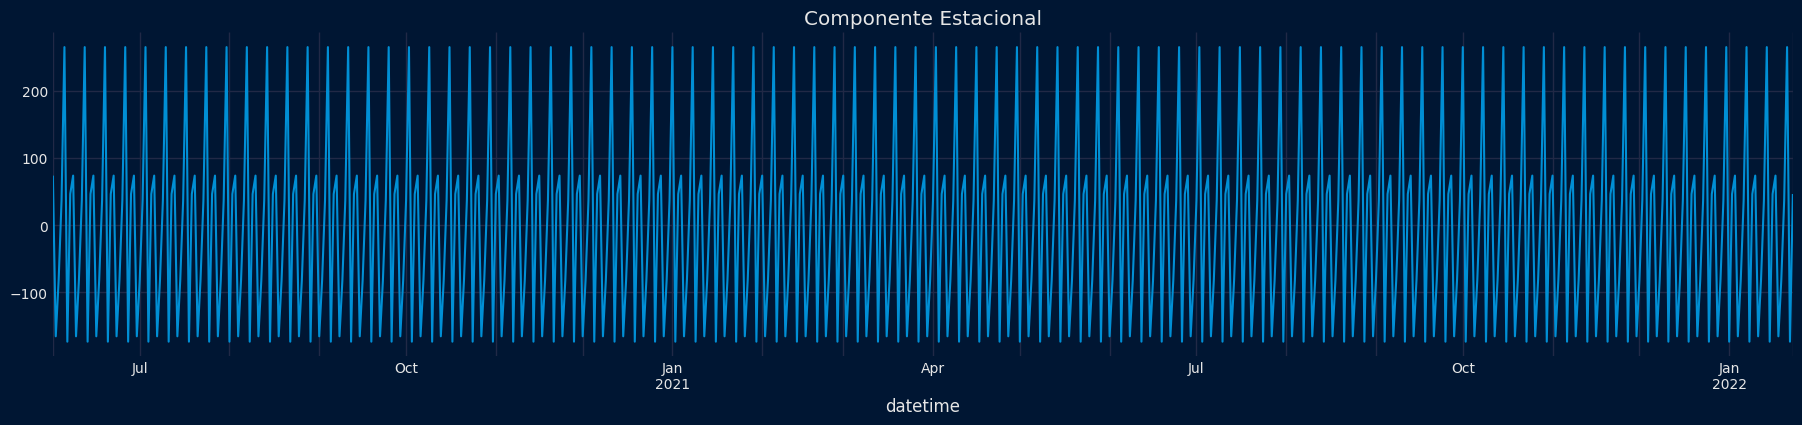

In [ ]:
# Zoom a la componente estacional
fig, ax = plt.subplots(figsize=(20, 4))
res_decompose.seasonal.plot(ax=ax)
ax.set_title('Componente Estacional')
plt.show()

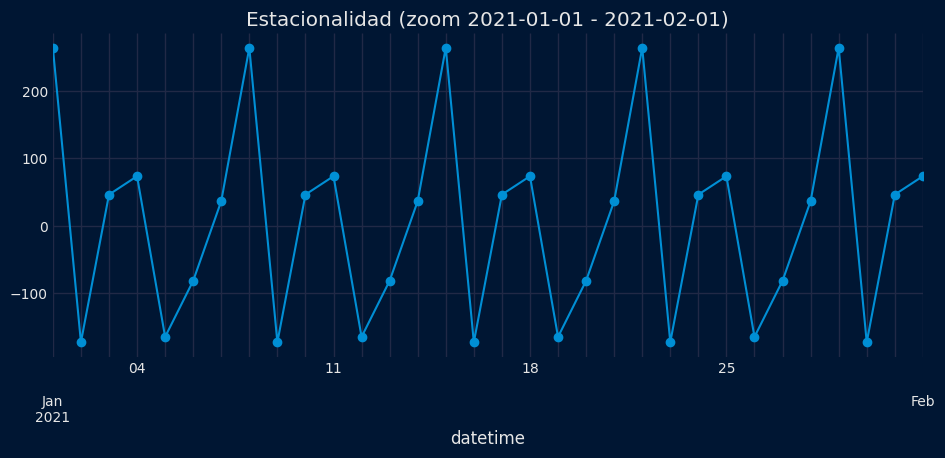

In [22]:
# Zoom: seleccionar intervalo por fechas (ajusta start/end)
start = '2021-01-01'
end   = '2021-02-01'
res_decompose.seasonal.loc[start:end].plot(figsize=(10,4), marker='o', title=f'Estacionalidad (zoom {start} - {end})')
plt.show()


In [19]:
# Test de Dickey-Fuller
from statsmodels.tsa.stattools import adfuller

print('Test de Estacionariedad de Dickey-Fuller')
adfuller_result = adfuller(data_reduced['Number of flights'])
print(f'ADF Estadístico: {adfuller_result[0]}, p-valor: {adfuller_result[1]}')

Test de Estacionariedad de Dickey-Fuller
ADF Estadístico: -1.6850003370153828, p-valor: 0.43885685246561673


Se evidencia que la serie no es estacionaria, por lo que se procede a diferenciar la serie para lograr la estacionariedad requerida para el modelo.

# **6. Preparación de Datos**
- Diferenciar la serie.
- Identificar su comportamiento estacional.

In [23]:
data_diff = data_reduced['Number of flights'].diff().dropna()

Test de estacionaridad
ADF Estadístico: -5.1455456898764655, p-valor: 1.1345186017203665e-05


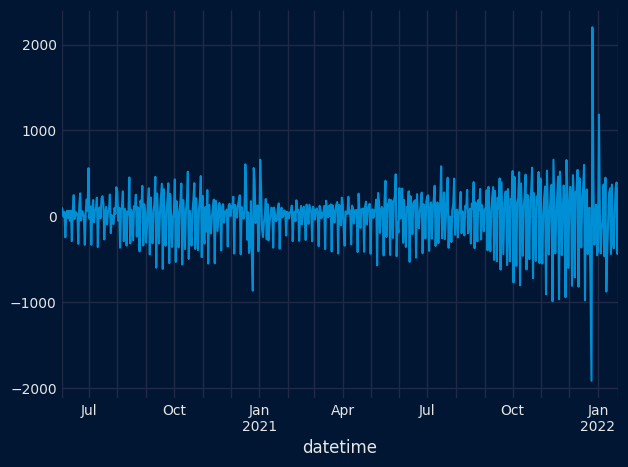

In [24]:
print('Test de estacionaridad')
adfuller_result = adfuller(data_diff)
print(f'ADF Estadístico: {adfuller_result[0]}, p-valor: {adfuller_result[1]}')
data_diff.plot()
plt.show()

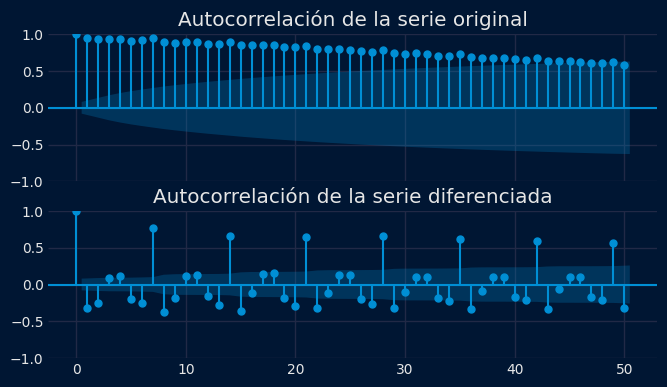

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Gráfico de autocorrelación
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_acf(data_reduced['Number of flights'], ax=ax[0], lags=50, alpha = 0.05)
ax[0].set_title('Autocorrelación de la serie original')
plot_acf(data_diff, ax=ax[1], lags=50, alpha = 0.05)
ax[1].set_title('Autocorrelación de la serie diferenciada')
plt.show()

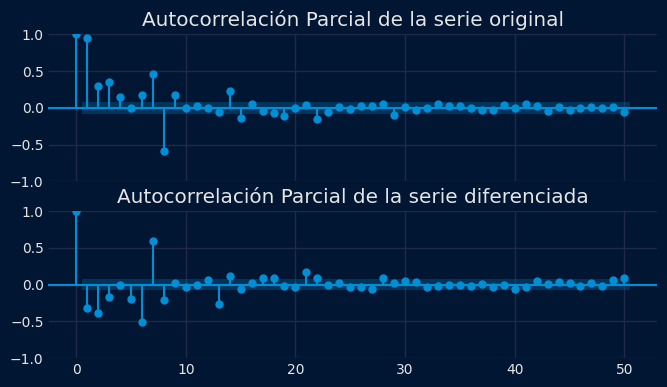

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Gráfico de autocorrelación parcial
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_pacf(data_reduced['Number of flights'], ax=ax[0], lags=50, alpha = 0.05)
ax[0].set_title('Autocorrelación Parcial de la serie original')
plot_pacf(data_diff, ax=ax[1], lags=50, alpha = 0.05)
ax[1].set_title('Autocorrelación Parcial de la serie diferenciada')
plt.show()

Al ser un muestreo semanal, el patrón estacional se repite cada 7 días, por lo que se realiza una diferenciación estacional de orden 7.

In [29]:
# Diferenciación de la serie estacional
data_diff_7 = data_reduced['Number of flights'].diff().diff(7).dropna() # data y no estacional, la vuelvo estacionaria, la componente estacional la vuelvo estacionar luego.
adfuller_result = adfuller(data_diff_7)
print(f'ADF Estadístico: {adfuller_result[0]}, p-valor: {adfuller_result[1]}')

ADF Estadístico: -12.7349347693458, p-valor: 9.204152124459323e-24


<Figure size 700x300 with 0 Axes>

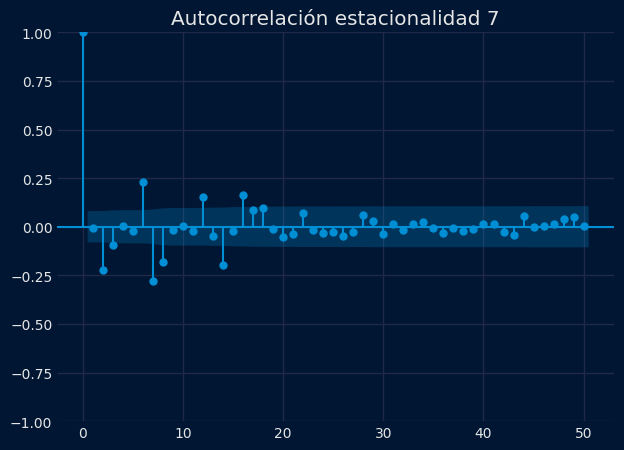

In [31]:
# Gráfico de autocorrelación de la serie estacionaria estacional
plt.figure(figsize=(7, 3))
plot_acf(data_diff_7, lags=50, alpha=0.05)
plt.title('Autocorrelación estacionalidad 7')
plt.show()

<Figure size 700x300 with 0 Axes>

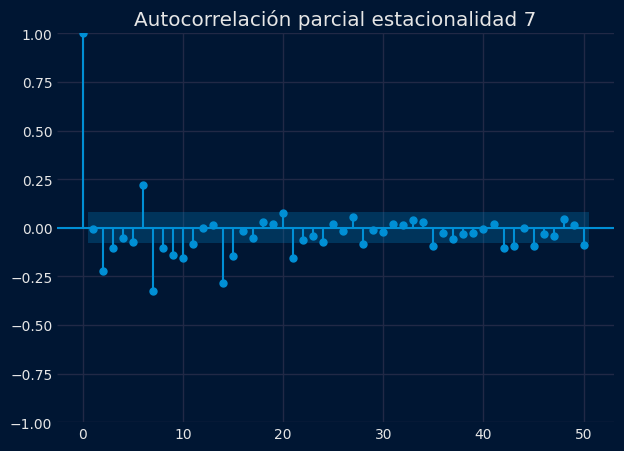

In [32]:
# Gráfico de autocorrelación parcial de la serie estacionaria estacional
plt.figure(figsize=(7, 3))
plot_pacf(data_diff_7, lags=50, alpha=0.05)
plt.title('Autocorrelación parcial estacionalidad 7')
plt.show()

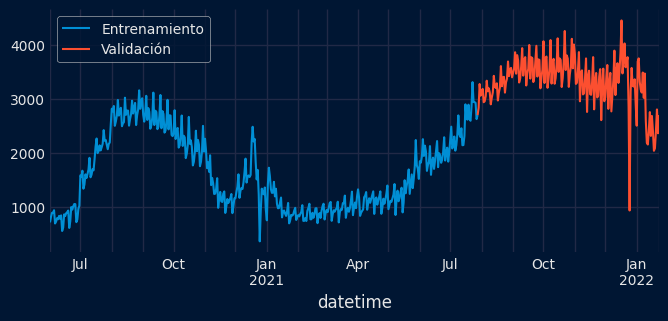

In [34]:
# Separar en entrenamiento y prueba
end_train = '2021-07-28'
data_train = data_reduced['Number of flights'].loc[:end_train]
data_test = data_reduced['Number of flights'].loc[end_train:]
plt.figure(figsize=(7, 3))
data_train.plot(label = 'Entrenamiento')
data_test.plot(label = 'Validación')
plt.legend()
plt.show()

# **7. Modelado**
- ARIMA
- Forecaster
- RNA Secuencial

## ARIMA

In [35]:
# ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax = SARIMAX(endog=data_train, order=(3, 1, 2), seasonal_order=(0, 1, 0, 7))
modelo_sarimax = modelo_sarimax.fit(disp = 0)
modelo_sarimax.summary()

c:\Users\pabli\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\pabli\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                  Number of flights   No. Observations:                  423
Model:             SARIMAX(3, 1, 2)x(0, 1, [], 7)   Log Likelihood               -2682.688
Date:                            Sat, 25 Oct 2025   AIC                           5377.376
Time:                                    15:41:51   BIC                           5401.546
Sample:                                06-01-2020   HQIC                          5386.933
                                     - 07-28-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1039      0.036     -2.924      0.003      -0.174      -0.034
ar.L2          0.7221      0.044     16.533      0.000       0.636       0.808
ar.L3         -0.1024      0.049     -2.079      0.038      -0.199      -0.006
ma.L1          0.0090      0.036      0.255      0.799      -0.061       0.079
ma.L2         -0.9688      0.035    -28.012      0.000      -1.037      -0.901
sigma2      2.402e+04    716.791     33.505      0.000    2.26e+04    2.54e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              5562.68
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.14   Skew:                            -2.04
Prob(H) (two-sided):                  0.45   Kurtosis:                        20.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [36]:
pred_sarimax = modelo_sarimax.get_forecast(steps=len(data_test)).predicted_mean
pred_sarimax.name = 'predicciones_sarimax'
display(pred_sarimax.head(4))

2021-07-29    2965.608106
2021-07-30    3436.040937
2021-07-31    3059.490416
2021-08-01    3072.487068
Freq: D, Name: predicciones_sarimax, dtype: float64

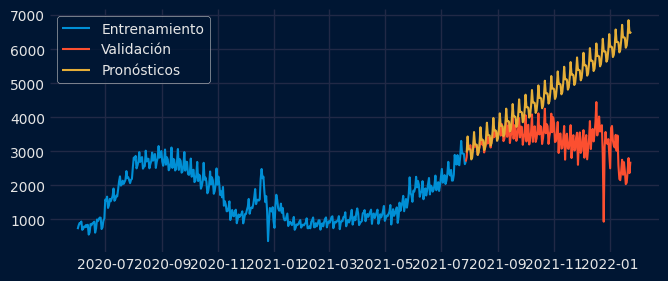

In [37]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(pred_sarimax, label='Pronósticos')
plt.legend()
plt.show()

In [38]:
from sklearn.metrics import mean_absolute_percentage_error
mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)
mape_sarimax

np.float64(0.48893363870530476)

## MODELOS ML

In [39]:
#Forecaster
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals

c:\Users\pabli\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


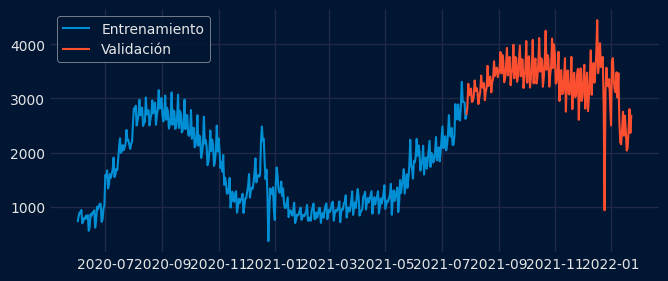

In [40]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.legend()
plt.show()

## Forecaster de Regresión Lineal

In [41]:
forecaster_1 = ForecasterRecursive(regressor= LinearRegression(),
                                    lags = 15, window_features= RollingFeatures(stats= ['mean'], window_sizes=10))
forecaster_1.fit(y = data_train, store_in_sample_residuals= True)
forecaster_1

=================== 
ForecasterRecursive 
=================== 
Regressor: LinearRegression 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: Number of flights 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-07-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False} 
fit_kwargs: {} 
Creation date: 2025-10-25 15:45:51 
Last fit date: 2025-10-25 15:45:51 
Skforecast version: 0.18.0 
Python version: 3.12.4 
Forecaster id: None

In [42]:
predictions_1 = forecaster_1.predict(steps = len(data_test))
predictions_1

2021-07-29    2831.121021
2021-07-30    3139.866227
2021-07-31    2852.735901
2021-08-01    2857.198765
2021-08-02    2895.296492
                 ...     
2022-01-20    2326.738103
2022-01-21    2346.676911
2022-01-22    2324.131834
2022-01-23    2336.250863
2022-01-24    2331.782198
Freq: D, Name: pred, Length: 180, dtype: float64

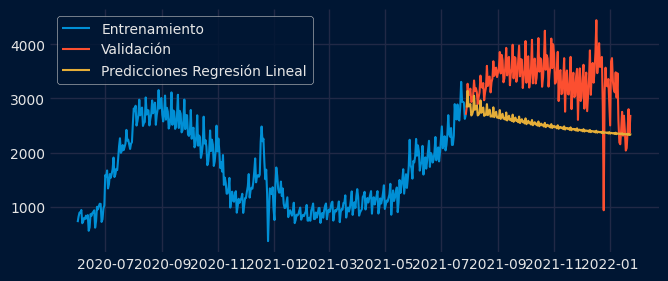

In [43]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_1, label='Predicciones Regresión Lineal')
plt.legend()
plt.show()

In [44]:
mean_absolute_percentage_error(data_test, predictions_1)

np.float64(0.24299418870080888)

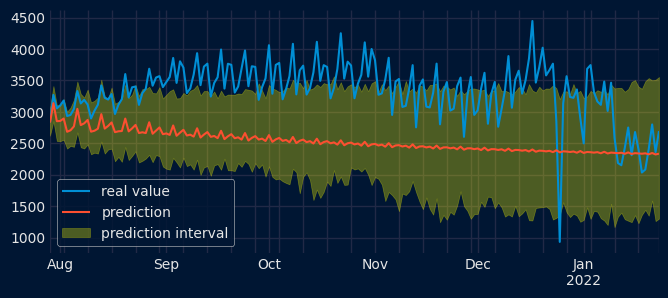

In [45]:
predictions_1_interval = forecaster_1.predict_interval(steps=len(data_test) -1,
                                                        interval=[5, 95],
                                                        method= 'bootstrapping', n_boot=100)
plot_prediction_intervals(predictions= predictions_1_interval, y_true= data_test, target_variable= 'Number of flights', 
                            kwargs_fill_between= {'color':'yellow', 'alpha':0.3})
plt.show()

## Forecaster de Árboles de Decisión con búsqeuda de hiperparámetros

In [46]:
forecaster_2 = ForecasterRecursive(regressor= DecisionTreeRegressor(random_state=42),
                                    lags = 15, window_features= RollingFeatures(stats= ['mean'], window_sizes=10))
forecaster_2.fit(y = data_train, store_in_sample_residuals= True)
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: Number of flights 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-07-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-25 15:47:59 
Last fit date: 2025-10-25 15:47:59 
Skforecast version: 0.18.0 
Python version: 3.12.4 
Forecaster id: None

In [47]:
predictions_2 = forecaster_2.predict(steps = len(data_test))
predictions_2

2021-07-29    2923.0
2021-07-30    3018.0
2021-07-31    2827.0
2021-08-01    2827.0
2021-08-02    3008.0
               ...  
2022-01-20    2754.0
2022-01-21    3008.0
2022-01-22    2330.0
2022-01-23    2409.0
2022-01-24    2963.0
Freq: D, Name: pred, Length: 180, dtype: float64

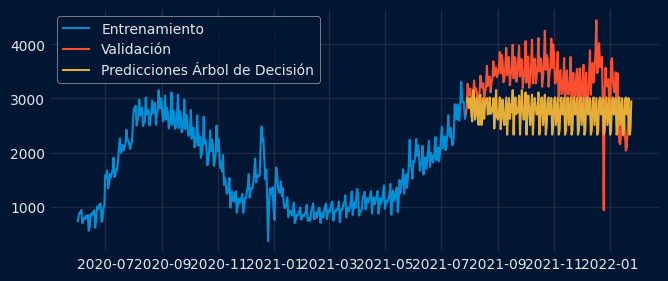

In [48]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_2, label='Predicciones Árbol de Decisión')
plt.legend()
plt.show()

In [49]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold
forecaster_2 = ForecasterRecursive(regressor= DecisionTreeRegressor(random_state=42),
                                    lags = 10)
# Búsqueda de la ventana
lags_grid ={'lags_1':3, 'lags_2':10, 'lags_3':[1, 2, 3, 12]}
# Búsqueda de hiperparámetros del regresor
param_grid = {'max_depth': [5, 10, 20], 'criterion': ['squared_error', 'poisson', 'absolute_error', 'friedman_mse']}
# Folds
cv = TimeSeriesFold(steps= 12, initial_train_size= len(data_test), refit= False) 
# Implementación de la búsqueda
results = grid_search_forecaster(forecaster= forecaster_2,
                                    y= data_train,
                                    param_grid= param_grid,
                                    lags_grid= lags_grid,
                                    cv= cv,
                                    metric= 'mean_squared_error',
                                    return_best= True,
                                    n_jobs= -1,
                                    verbose= False,
                                    show_progress= True)
results

lags grid: 100%|██████████| 3/3 [00:13<00:00,  4.42s/it]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 5}
  Backtesting metric: 89859.45541318545


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 5}",89859.455413,squared_error,5
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 5}",89859.455413,friedman_mse,5
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'poisson', 'max_depth': 5}",102613.370751,poisson,5
3,"[1, 2, 3]",lags_1,"{'criterion': 'absolute_error', 'max_depth': 5}",116948.232510,absolute_error,5
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'poisson', 'max_depth': 10}",121513.382144,poisson,10
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 10}",125864.730224,friedman_mse,10
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 10}",125864.730224,squared_error,10
7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 20}",127781.106996,squared_error,20
8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 20}",127781.106996,friedman_mse,20
9,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 5}",136785.796175,poisson,5


In [50]:
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10] 
Window features: None 
Window size: 10 
Series name: Number of flights 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-07-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 5, 'max_features':
    None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-25 15:49:57 
Last fit date: 2025-10-25 15:50:10 
Skforecast version: 0.18.0 
Python version: 3.12.4 
Forecaster id: None

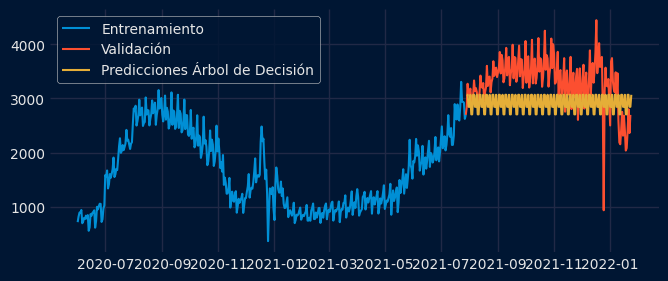

In [51]:
predictions_2 = forecaster_2.predict(len(data_test))
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_2, label='Predicciones Árbol de Decisión')
plt.legend()
plt.show()

In [52]:
mean_absolute_percentage_error(data_test, predictions_2)

np.float64(0.16381661727509633)

## Forecaster de Bosque Aleatorio con búsqueda de hiperparámetros

In [53]:
forecaster_3 = ForecasterRecursive(regressor= RandomForestRegressor(random_state=42),
                                    lags = 10)
# Búsqueda de la ventana
lags_grid ={'lags_1':3, 'lags_2':10, 'lags_3':[1, 2, 3, 12]}
# Búsqueda de hiperparámetros del regresor
param_grid = {'max_depth': [5, 10, 20], 'criterion': ['squared_error', 'poisson', 'absolute_error', 'friedman_mse'],
                'n_estimators': [100, 200, 300]}
# Folds
cv = TimeSeriesFold(steps= 12, initial_train_size= len(data_test), refit= False) 
# Implementación de la búsqueda
results = grid_search_forecaster(forecaster= forecaster_3,
                                    y= data_train,
                                    param_grid= param_grid,
                                    lags_grid= lags_grid,
                                    cv= cv,
                                    metric= 'mean_squared_error',
                                    return_best= True,
                                    n_jobs= -1,
                                    verbose= False,
                                    show_progress= True)

lags grid: 100%|██████████| 3/3 [04:19<00:00, 86.45s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 5, 'n_estimators': 100}
  Backtesting metric: 124260.27264423868


In [54]:
forecaster_3

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10] 
Window features: None 
Window size: 10 
Series name: Number of flights 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-07-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'absolute_error',
    'max_depth': 5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples':
    None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1,
    'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst':
    None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False,
    'random_state': 42, 'verbose': 0, 'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-25 15:54:32 
Last fit date: 2025-10-25 15:58:53 
Skforecast version: 0.18.0 
Python version: 3.12.4 
Forecaster id: None

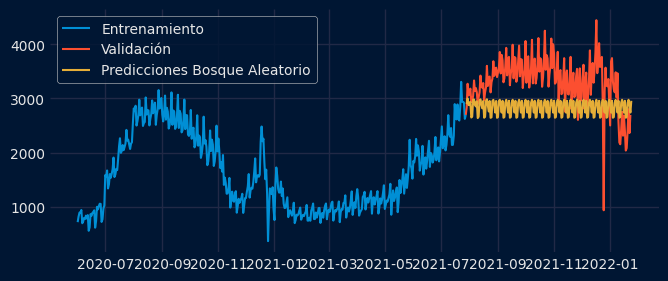

In [55]:
predictions_3 = forecaster_3.predict(len(data_test))
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_3, label='Predicciones Bosque Aleatorio')
plt.legend()
plt.show()

In [56]:
mean_absolute_percentage_error(data_test, predictions_3)

np.float64(0.1776286729149598)

## Redes Neuronales Recurrentes

In [57]:
# Redes Neuronales Artificiales
from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

## Red con recurrent_layer = 'RNN'

In [ ]:
model_rna = create_and_compile_model(series= pd.DataFrame(data_train), 
                                        levels= ['Number of flights'], lags= 24, steps= 1, recurrent_layer= 'RNN', recurrent_units= 100, dense_units= 64)
model_rna.summary()

keras version: 3.11.3
Using backend: tensorflow
tensorflow version: 2.20.0



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,729 (65.35 KB)

 Trainable params: 16,729 (65.35 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
forecaster_4 = ForecasterRnn(regressor= model_rna,
                                levels = ['Number of flights'],
                                lags= 24,
                                transformer_series= MinMaxScaler(),
                                fit_kwargs= {'epochs': 25,
                                            'batch_size': 512,
                                            'callbacks':[EarlyStopping(monitor='val_loss', restore_best_weights=True)],
                                            'series_val': pd.DataFrame(data_test)})
forecaster_4.fit(pd.DataFrame(data_train))

Epoch 1/25


c:\Users\pabli\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.1075 - val_loss: 1.2846
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.3303 - val_loss: 0.4441
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0643 - val_loss: 0.1390
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0484 - val_loss: 0.0622
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0720 - val_loss: 0.0778


In [60]:
forecaster_4

============= 
ForecasterRnn 
============= 
Regressor: <Functional name=functional, built=True> 
Layers names: ['series_input', 'rnn_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: Number of flights 
Target series (levels): ['Number of flights'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-07-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: {'name': 'functional', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input'}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'SimpleRNN', 'config': {'name': 'rnn_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 100, 'activation': 'tanh', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'rnn_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 100]}, 'name': 'dense_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 100), 'dtype': 'float32', 'keras_history': ['rnn_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'output_dense_td_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64]}, 'name': 'output_dense_td_layer', 'inbound_nodes

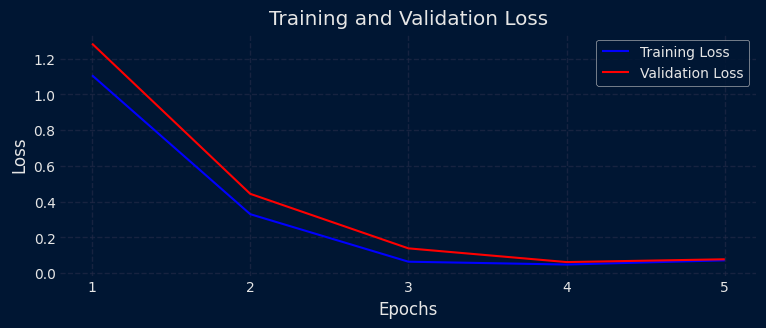

In [61]:
fig, ax = plt.subplots(figsize=(8, 3))
plot = forecaster_4.plot_history(ax=ax)

In [69]:
from skforecast.model_selection import backtesting_forecaster_multiseries
cv = TimeSeriesFold(steps= forecaster_4.max_step, 
                    initial_train_size= len(data_test), 
                    refit= False)
metrics, predictions_4 = backtesting_forecaster_multiseries(forecaster= forecaster_4,
                                                            series= pd.DataFrame(data_train),
                                                            cv = cv,
                                                            levels= forecaster_4.levels,
                                                            metric= 'mean_absolute_percentage_error', verbose= False)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0427WARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x000001BD9B941C60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0427 - val_loss: 0.1364
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0274 - val_loss: 0.1899


100%|██████████| 243/243 [00:23<00:00, 10.29it/s]


In [70]:
metrics

,levels,mean_absolute_percentage_error
0,Number of flights,0.41053


In [71]:
predictions_4

,level,fold,pred
2020-11-28,Number of flights,0,1912.493652
2020-11-29,Number of flights,1,1957.868042
2020-11-30,Number of flights,2,1637.127686
2020-12-01,Number of flights,3,1645.242798
2020-12-02,Number of flights,4,1819.686035
...,...,...,...
2021-07-24,Number of flights,238,2479.796143
2021-07-25,Number of flights,239,2574.958740
2021-07-26,Number of flights,240,2515.696045
2021-07-27,Number of flights,241,2413.163330


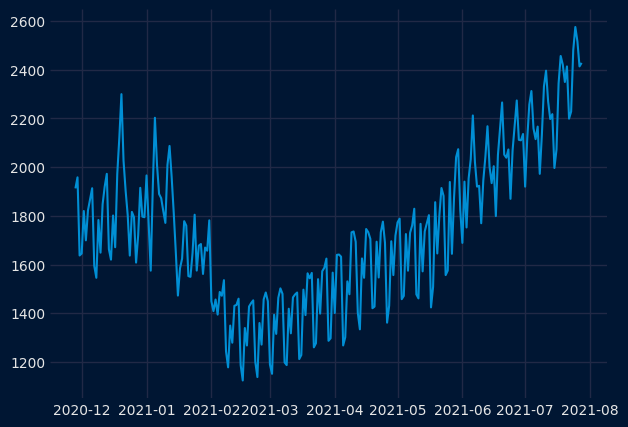

In [72]:
plt.plot(predictions_4['pred'])

## Red con recurrent_layer = 'LSTM'

In [75]:
model_rna_2 = create_and_compile_model(series= pd.DataFrame(data_train), # Se puede cambiar recurrent_layer a 'LSTM'
                                        levels= ['Number of flights'], lags= 24, steps= 1, recurrent_layer= 'LSTM', recurrent_units= 100, dense_units= 64)
model_rna_2.summary()

keras version: 3.11.3
Using backend: tensorflow
tensorflow version: 2.20.0



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,329 (184.88 KB)

 Trainable params: 47,329 (184.88 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
forecaster_5 = ForecasterRnn(regressor= model_rna_2,
                                levels = ['Number of flights'],
                                lags= 24,
                                transformer_series= MinMaxScaler(),
                                fit_kwargs= {'epochs': 25,
                                            'batch_size': 512,
                                            'callbacks':[EarlyStopping(monitor='val_loss', restore_best_weights=True)],
                                            'series_val': pd.DataFrame(data_test)})
forecaster_5.fit(pd.DataFrame(data_train))

Epoch 1/25


c:\Users\pabli\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2278 - val_loss: 0.7208
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.1741 - val_loss: 0.5514
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.1329 - val_loss: 0.4091
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.0973 - val_loss: 0.2776
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.0648 - val_loss: 0.1532
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.0354 - val_loss: 0.0553
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.0143 - val_loss: 0.0191
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.0106 - val_loss: 0.0609


In [77]:
forecaster_5

============= 
ForecasterRnn 
============= 
Regressor: <Functional name=functional_1, built=True> 
Layers names: ['series_input', 'lstm_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: Number of flights 
Target series (levels): ['Number of flights'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-07-28 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: {'name': 'functional_1', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input'}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'LSTM', 'config': {'name': 'lstm_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 100, 'activation': 'tanh', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'unit_forget_bias': True, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0, 'seed': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'lstm_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 100]}, 'name': 'dense_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 100), 'dtype': 'float32', 'keras_history': ['lstm_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'output_dense_td_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config'

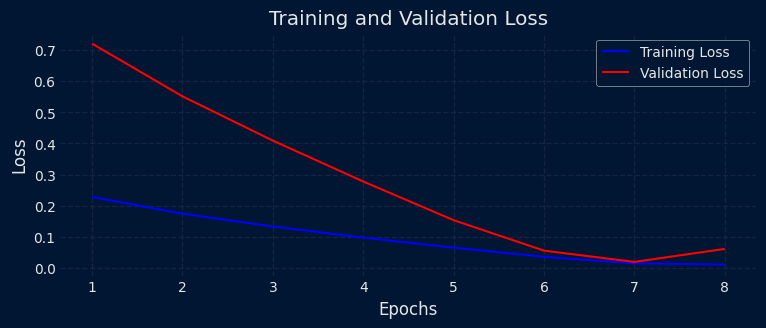

In [78]:
fig, ax = plt.subplots(figsize=(8, 3))
plot = forecaster_5.plot_history(ax=ax)

In [79]:
from skforecast.model_selection import backtesting_forecaster_multiseries
cv = TimeSeriesFold(steps= forecaster_5.max_step, 
                    initial_train_size= len(data_test), 
                    refit= False)
metrics, predictions_5 = backtesting_forecaster_multiseries(forecaster= forecaster_5,
                                                            series= pd.DataFrame(data_train),
                                                            cv = cv,
                                                            levels= forecaster_5.levels,
                                                            metric= 'mean_absolute_percentage_error', verbose= False)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0146 - val_loss: 0.0427
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0280 - val_loss: 0.0439


100%|██████████| 243/243 [00:21<00:00, 11.08it/s]


In [80]:
metrics

,levels,mean_absolute_percentage_error
0,Number of flights,0.266098


In [81]:
predictions_5

,level,fold,pred
2020-11-28,Number of flights,0,1475.161865
2020-11-29,Number of flights,1,1439.181274
2020-11-30,Number of flights,2,1419.911743
2020-12-01,Number of flights,3,1412.646362
2020-12-02,Number of flights,4,1412.005615
...,...,...,...
2021-07-24,Number of flights,238,2925.023193
2021-07-25,Number of flights,239,2964.751709
2021-07-26,Number of flights,240,3000.820557
2021-07-27,Number of flights,241,3029.978027


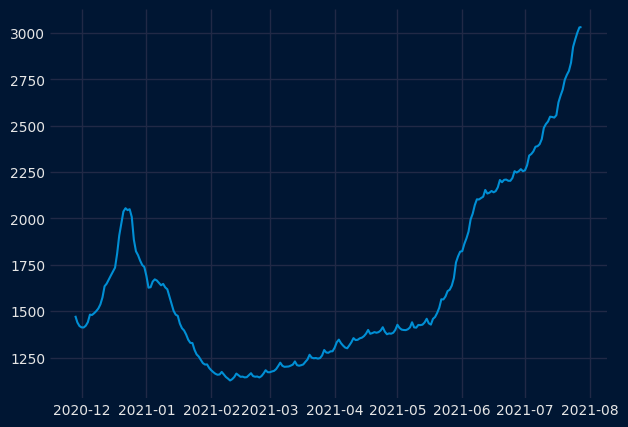

In [82]:
plt.plot(predictions_5['pred'])